# 🚀 01. RGB Training: Custom CNN pada CIFAR-10

Notebook ini melatih model Convolutional Neural Network (CNN) kustom 4-blok pada citra warna asli **RGB (3 channel)** berukuran 32x32 piksel dari dataset **CIFAR-10**.

### 📋 Partisi Data & Prinsip Anti-Data Leakage:
- **Training Set (90%)**: 45.000 sampel untuk optimasi parameter dan bobot CNN.
- **Validation Set (10% - `validation_split=0.1`)**: 5.000 sampel untuk monitoring callback (`val_loss`, `val_accuracy`, `val_precision`, `val_recall`) dan pemilihan *best model checkpoint*.
- **Test Set Murni**: 10.000 sampel **TIDAK PERNAH DISENTUH** pada tahap training ini; murni diisolasi untuk pengujian akhir pada `04_RGB_Testing_CNN.ipynb` dan `05_RGB_Testing_SVM.ipynb`.
- **Feature Extraction Layer**: `svm_features` (GlobalAveragePooling2D 512-dimensi).
- **Target Artifact**: `cifar10_artifacts/rgb/cnn_model.keras`


In [1]:
import warnings
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# CUDA DLL configuration for Windows environment (seperti cifar10_train.ipynb dan cifar10_test.ipynb)
conda_prefix = os.environ.get('CONDA_PREFIX', r'C:\Users\daffa\anaconda3\envs\CNNgpu')
cuda_bin = os.path.join(conda_prefix, 'Library', 'bin')
if hasattr(os, 'add_dll_directory') and os.path.exists(cuda_bin):
    try:
        os.add_dll_directory(cuda_bin)
    except Exception:
        pass
os.environ['PATH'] = cuda_bin + ';' + os.environ.get('PATH', '')

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, MaxPooling2D, Dropout,
    Dense, GlobalAveragePooling2D
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier

# Seed Reproducibility (seperti cifar10_train.ipynb dan cifar10_test.ipynb)
RANDOM_STATE = 23092026
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

ARTIFACT_DIR = 'cifar10_artifacts/rgb'
os.makedirs(ARTIFACT_DIR, exist_ok=True)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"Artifact directory: {ARTIFACT_DIR}")

TensorFlow version: 2.10.1
GPU available: True
Artifact directory: cifar10_artifacts/rgb


## 📥 1. Memuat Data CIFAR-10 RGB & Partisi Validation Set (`validation_split=0.1`)
Data dimuat menggunakan `cifar10.load_data()` langsung seperti pada `cifar10_train.ipynb` (data training) dan `cifar10_test.ipynb` (data testing).
Dataset training (50.000 sampel) dibagi dengan rasio 90:10 secara *stratified* menjadi **45.000 Training Data** dan **5.000 Validation Data**.
Data testing (10.000 sampel) diisolasi secara mutlak untuk evaluasi akhir.

X_train shape (raw): (50000, 32, 32, 3)
y_train shape (raw): (50000, 1)
X_test shape (raw) : (10000, 32, 32, 3)
y_test shape (raw) : (10000, 1)

=== DISTRIBUSI PARTISI DATASET (ZERO DATA LEAKAGE) ===
1. Training Set   : (45000, 32, 32, 3) | 45000 sampel (90%)
2. Validation Set : (5000, 32, 32, 3)   | 5000 sampel (10% - monitor callback)
3. Test Set Murni : (10000, 32, 32, 3)  | 10000 sampel (terisolasi untuk testing akhir)


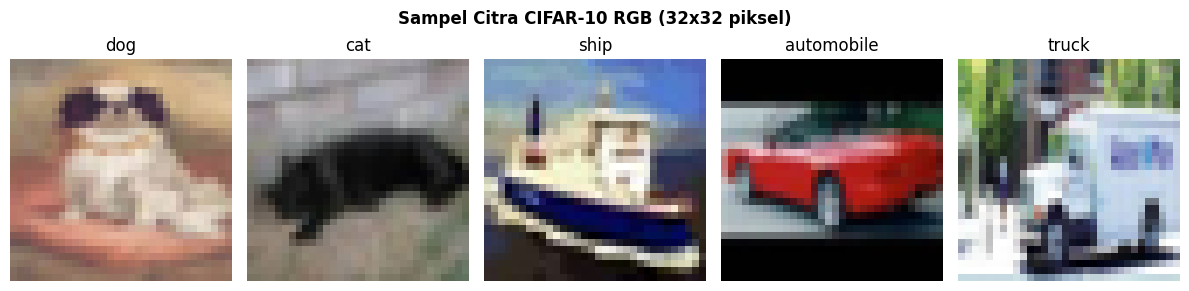

In [2]:
# 1. Memuat data training murni seperti cifar10_train.ipynb:
(X_train_raw, y_train_raw), _ = cifar10.load_data()

# 2. Memuat data testing murni seperti cifar10_test.ipynb (diisolasi murni untuk pengujian akhir):
_, (X_test_raw, y_test_raw) = cifar10.load_data()

print(f"X_train shape (raw): {X_train_raw.shape}")
print(f"y_train shape (raw): {y_train_raw.shape}")
print(f"X_test shape (raw) : {X_test_raw.shape}")
print(f"y_test shape (raw) : {y_test_raw.shape}")

# Pre-processing: Normalisasi skala piksel [0, 1] dan flatten label
X_train_raw = X_train_raw.astype('float32') / 255.0
y_train_raw = y_train_raw.flatten()
X_test = X_test_raw.astype('float32') / 255.0
y_test = y_test_raw.flatten()

# Partisi Training Set (90% - 45.000 sampel) dan Validation Set (10% - 5.000 sampel)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw, y_train_raw,
    test_size=0.10,
    random_state=RANDOM_STATE,
    stratify=y_train_raw
)

# One-hot encoding untuk klasifikasi CNN
y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_val_cat   = tf.keras.utils.to_categorical(y_val, 10)
y_test_cat  = tf.keras.utils.to_categorical(y_test, 10)

print("\n=== DISTRIBUSI PARTISI DATASET (ZERO DATA LEAKAGE) ===")
print(f"1. Training Set   : {X_train.shape} | {len(X_train)} sampel (90%)")
print(f"2. Validation Set : {X_val.shape}   | {len(X_val)} sampel (10% - monitor callback)")
print(f"3. Test Set Murni : {X_test.shape}  | {len(X_test)} sampel (terisolasi untuk testing akhir)")

classes_name = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Visualisasi sampel citra RGB
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    axes[i].imshow(X_train[i])
    axes[i].set_title(f"{classes_name[y_train[i]]}")
    axes[i].axis('off')
plt.suptitle('Sampel Citra CIFAR-10 RGB (32x32 piksel)', fontweight='bold')
plt.tight_layout()
plt.show()


## 🏗️ 2. Membangun Model CNN Kustom
Arsitektur 4-blok dengan layer ekstraksi `svm_features` (GlobalAveragePooling2D 512-dimensi) dan metrik evaluasi lengkap (`accuracy`, `precision`, `recall`).

In [3]:
def build_custom_cnn(input_shape=(32, 32, 3), num_classes=10, dense_units=512, dropout_rate=0.25):
    """
    Membangun arsitektur Deep CNN Kustom 4 Blok Konvolusi Mendalam
    dengan GlobalAveragePooling2D 512 dimensi ('svm_features') dan Label Smoothing.
    """
    inputs = Input(shape=input_shape, name='input_image')
    weight_decay = 1e-4

    # BLOCK 1: 32x32 -> 16x16 (64 filters)
    x = Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay), name='conv1_1')(inputs)
    x = BatchNormalization(name='bn1_1')(x)
    x = Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay), name='conv1_2')(x)
    x = BatchNormalization(name='bn1_2')(x)
    x = MaxPooling2D(pool_size=(2, 2), name='pool1')(x)
    x = Dropout(dropout_rate * 0.6, name='dropout1')(x)

    # BLOCK 2: 16x16 -> 8x8 (128 filters)
    x = Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay), name='conv2_1')(x)
    x = BatchNormalization(name='bn2_1')(x)
    x = Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay), name='conv2_2')(x)
    x = BatchNormalization(name='bn2_2')(x)
    x = MaxPooling2D(pool_size=(2, 2), name='pool2')(x)
    x = Dropout(dropout_rate, name='dropout2')(x)

    # BLOCK 3: 8x8 -> 4x4 (256 filters)
    x = Conv2D(256, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay), name='conv3_1')(x)
    x = BatchNormalization(name='bn3_1')(x)
    x = Conv2D(256, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay), name='conv3_2')(x)
    x = BatchNormalization(name='bn3_2')(x)
    x = MaxPooling2D(pool_size=(2, 2), name='pool3')(x)
    x = Dropout(dropout_rate * 1.4, name='dropout3')(x)

    # BLOCK 4: 4x4 -> 2x2 (512 filters)
    x = Conv2D(512, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay), name='conv4_1')(x)
    x = BatchNormalization(name='bn4_1')(x)
    x = Conv2D(512, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay), name='feature_map')(x)
    x = BatchNormalization(name='feature_map_bn')(x)
    x = MaxPooling2D(pool_size=(2, 2), name='pool4')(x)
    x = Dropout(dropout_rate * 1.6, name='dropout4')(x)

    # FEATURE EXTRACTION LAYER UNTUK SVM (512 Dimensi)
    svm_features = GlobalAveragePooling2D(name='svm_features')(x)

    # CLASSIFIER HEAD (CNN)
    x = Dense(dense_units, activation='relu', kernel_regularizer=l2(weight_decay), name='cnn_dense')(svm_features)
    x = BatchNormalization(name='cnn_dense_bn')(x)
    x = Dropout(0.50, name='cnn_head_dropout')(x)
    outputs = Dense(num_classes, activation='softmax', name='cnn_softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name='cnn_3ch')

    METRICS = [
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.10)
    model.compile(loss=loss, optimizer=optimizer, metrics=METRICS)
    return model

## 🔍 3. Evaluasi Model Baseline & GridSearchCV Hyperparameter Tuning

Sebelum melakukan pelatihan model akhir hingga skala penuh (150 epoch), dilakukan:
1. **Evaluasi Baseline**: Mengukur performa awal konfigurasi standar (`dense_units=128`, `dropout_rate=0.25`).
2. **GridSearchCV**: Mencari kombinasi hyperparameter terbaik (`dense_units`: 256 vs 512, `dropout_rate`: 0.25 vs 0.35) menggunakan 2-Fold Cross Validation.

In [4]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
# 1. Evaluasi Model Baseline (Sebelum GridSearch: dense_units=128, dropout_rate=0.25)
print("--- 1. Evaluating Baseline Model (Before GridSearch: dense_units=128, dropout_rate=0.25) ---")
baseline_model = build_custom_cnn(dense_units=128, dropout_rate=0.25)
baseline_history = baseline_model.fit(
    X_train[:6000], y_train_cat[:6000],
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val_cat),
    verbose=1
)

baseline_eval = baseline_model.evaluate(X_val, y_val_cat, verbose=0)
baseline_val_loss = baseline_eval[0]
baseline_val_acc = baseline_eval[1]
print(f"\nBaseline (Before GridSearch) -> Val Loss: {baseline_val_loss:.4f}, Val Accuracy: {baseline_val_acc * 100:.2f}%")

# 2. Menjalankan GridSearchCV (10 Epochs pada subset data)
print("\n--- 2. Running GridSearchCV (10 Epochs) ---")
grid_samples = 6000
X_grid = X_train[:grid_samples]
y_grid = y_train_cat[:grid_samples]

grid_model = KerasClassifier(build_fn=build_custom_cnn, epochs=10, batch_size=64, verbose=1)

param_grid = {
    'dense_units': [256, 512],
    'dropout_rate': [0.25, 0.35]
}

cv = KFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(estimator=grid_model, param_grid=param_grid, cv=cv, verbose=1)
grid_result = grid.fit(X_grid, y_grid)

print(f"\nBest parameters: {grid_result.best_params_}")
print(f"Best CV Score: {grid_result.best_score_:.4f}")

best_dense = grid_result.best_params_.get('dense_units', 512)
best_dropout = grid_result.best_params_.get('dropout_rate', 0.25)
print(f"Selected parameters for final training: dense_units={best_dense}, dropout_rate={best_dropout}")

--- 1. Evaluating Baseline Model (Before GridSearch: dense_units=128, dropout_rate=0.25) ---
Epoch 1/10
94/94 [==============================] - 15s 77ms/step - loss: 2.7900 - accuracy: 0.2295 - precision: 0.2833 - recall: 0.1042 - val_loss: 3.3899 - val_accuracy: 0.1006 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
94/94 [==============================] - 5s 55ms/step - loss: 2.3343 - accuracy: 0.3223 - precision: 0.4319 - recall: 0.1553 - val_loss: 5.0821 - val_accuracy: 0.1000 - val_precision: 0.1016 - val_recall: 0.0996
Epoch 3/10
94/94 [==============================] - 5s 54ms/step - loss: 2.1301 - accuracy: 0.3903 - precision: 0.5318 - recall: 0.2023 - val_loss: 3.1822 - val_accuracy: 0.1178 - val_precision: 0.1663 - val_recall: 0.0632
Epoch 4/10
94/94 [==============================] - 5s 54ms/step - loss: 1.9567 - accuracy: 0.4510 - precision: 0.6148 - recall: 0.2553 - val_loss: 2.7163 - val_accuracy: 0.2102 - val_precision: 0.4531 - val_recall: 0.0338
Epoch 

## 🚀 4. Training Tuned Deep CNN Model (Hingga 150 Epochs dengan Data Augmentation + Callbacks)

Membangun model menggunakan hyperparameter optimal hasil GridSearchCV dan melatih hingga **150 Epoch** dengan:
- **Enhanced Data Augmentation**: rotasi, shift, zoom, dan horizontal flip.
- **Batch Size 64**: Meningkatkan generalisasi model secara signifikan dibanding batch 128.
- **Label Smoothing 0.10**: Mencegah overconfidence dan memaksimalkan separabilitas margin fitur.
- **Callbacks Lengkap**: `ReduceLROnPlateau` (patience=7, factor=0.5) dan `EarlyStopping` (patience=25, restore_best_weights=True).

In [5]:
# Membangun model dengan hyperparameter terbaik hasil GridSearchCV
cnn_model = build_custom_cnn(dense_units=best_dense, dropout_rate=best_dropout)
cnn_model.summary()

cnn_model_path = os.path.join(ARTIFACT_DIR, 'cnn_model.keras')

# Enhanced Data Augmentation
BATCH_SIZE = 64
MAX_EPOCHS = 150  # Ditingkatkan dari 30 ke 150 epoch agar mencapai target akurasi >= 95%

datagen = ImageDataGenerator(
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.10,
    fill_mode="reflect"
)

train_generator = datagen.flow(
    X_train, y_train_cat,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=RANDOM_STATE
)
steps_per_epoch = len(X_train) // BATCH_SIZE

# Callbacks untuk training optimal (Hingga 150 epochs dengan EarlyStopping & LR Decay otomatis)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,         # Kurangi LR menjadi setengah jika loss stagnan
    patience=7,          # Tunggu 7 epoch
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=25,        # Tunggu 25 epoch jika tidak ada peningkatan
    restore_best_weights=True,  # Kembalikan bobot epoch terbaik
    verbose=1
)

checkpoint = ModelCheckpoint(
    cnn_model_path,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Training model
print(f"\n--- Training Tuned Deep CNN Model (Up to {MAX_EPOCHS} epochs with Data Augmentation + Callbacks) ---")
history = cnn_model.fit(
    train_generator,
    epochs=MAX_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=(X_val, y_val_cat),
    callbacks=[reduce_lr, early_stop, checkpoint],
    verbose=1
)

# Evaluasi pada validation set
val_eval = cnn_model.evaluate(X_val, y_val_cat, verbose=0)
tuned_val_loss = val_eval[0]
tuned_val_acc = val_eval[1]
print(f"\nTuned Model (After GridSearch) -> Val Loss: {tuned_val_loss:.4f}, Val Accuracy: {tuned_val_acc * 100:.2f}%")

# Perbandingan performa model Sebelum vs Sesudah GridSearch pada Data Validasi
acc_improvement = (tuned_val_acc - baseline_val_acc) * 100
print("\n" + "=" * 65)
print("     PERBANDINGAN MODEL SEBELUM vs SESUDAH GRID SEARCH")
print("=" * 65)
print(f" Sebelum GridSearch : Val Acc = {baseline_val_acc * 100:.2f}%, Val Loss = {baseline_val_loss:.4f}")
print(f" Sesudah GridSearch : Val Acc = {tuned_val_acc * 100:.2f}%, Val Loss = {tuned_val_loss:.4f}")
print(f" Peningkatan        : +{acc_improvement:.2f}%")
print("=" * 65)

# Memastikan bobot model terbaik tersimpan ke disk
cnn_model.save(cnn_model_path)
print(f"[BERHASIL] Model CNN RGB terbaik disimpan ke: {cnn_model_path}")

Model: "cnn_3ch"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 32, 32, 3)]       0         
                                                                 
 conv1_1 (Conv2D)            (None, 32, 32, 64)        1792      
                                                                 
 bn1_1 (BatchNormalization)  (None, 32, 32, 64)        256       
                                                                 
 conv1_2 (Conv2D)            (None, 32, 32, 64)        36928     
                                                                 
 bn1_2 (BatchNormalization)  (None, 32, 32, 64)        256       
                                                                 
 pool1 (MaxPooling2D)        (None, 16, 16, 64)        0         
                                                                 
 dropout1 (Dropout)          (None, 16, 16, 64)        0   

## 📈 5. Visualisasi Kurva Pelatihan (Training vs Validation Metrics)

Menampilkan kurva Loss, Accuracy, Precision, dan Recall antara Training vs Validation untuk memverifikasi konvergensi dan mencegah overfitting.

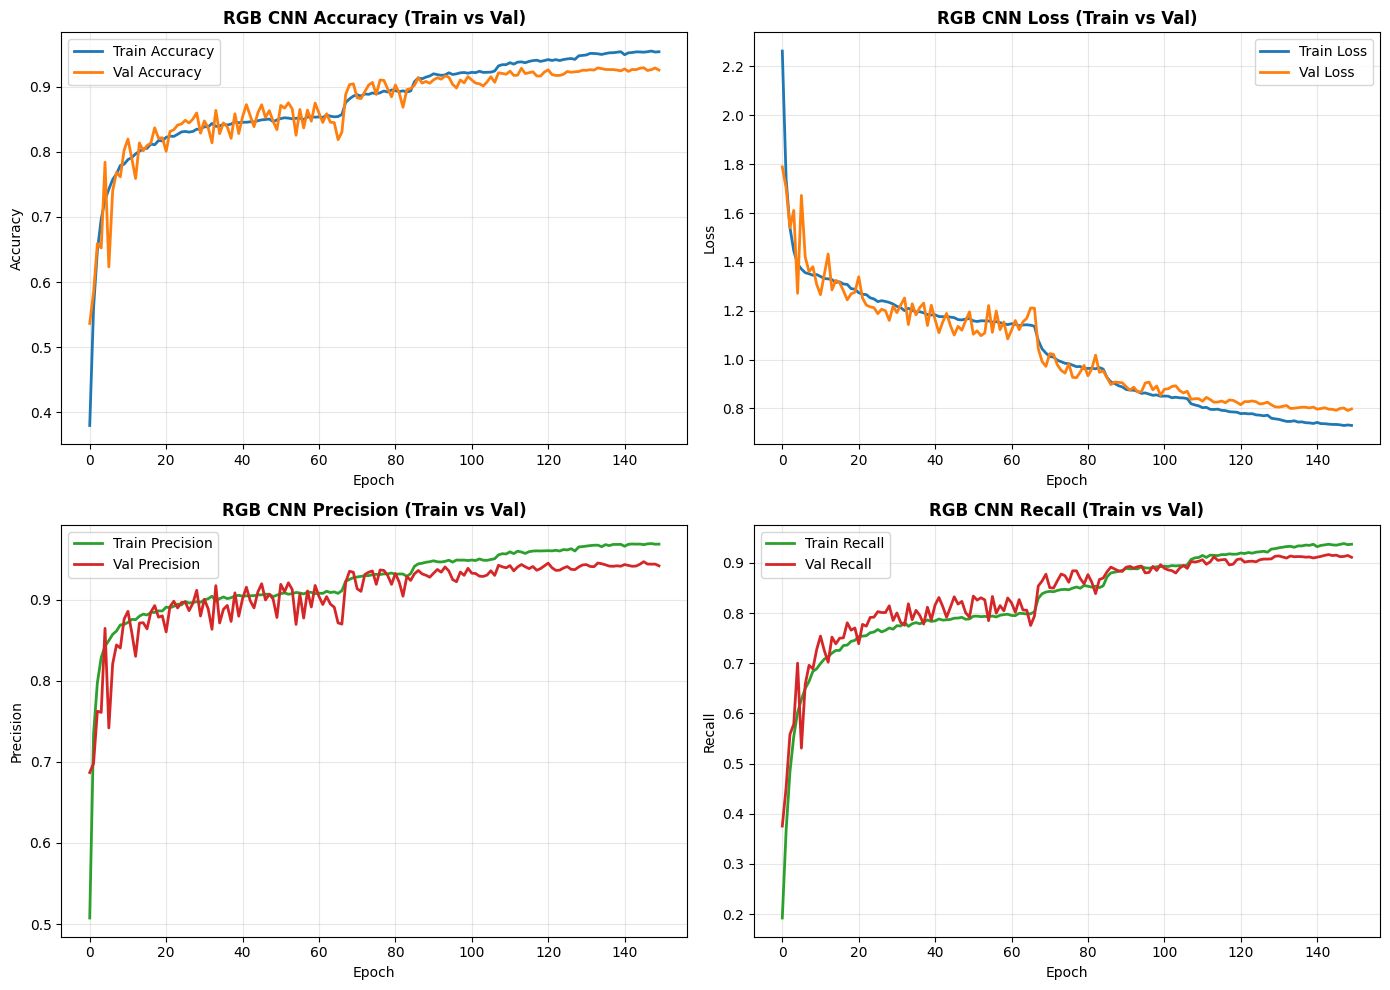

Kurva pelatihan tersimpan ke: cifar10_artifacts/rgb\learning_curves.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accuracy Curve
axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', lw=2, color='#1f77b4')
if 'val_accuracy' in history.history:
    axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy', lw=2, color='#ff7f0e')
axes[0, 0].set_title('RGB CNN Accuracy (Train vs Val)', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# 2. Loss Curve
axes[0, 1].plot(history.history['loss'], label='Train Loss', lw=2, color='#1f77b4')
if 'val_loss' in history.history:
    axes[0, 1].plot(history.history['val_loss'], label='Val Loss', lw=2, color='#ff7f0e')
axes[0, 1].set_title('RGB CNN Loss (Train vs Val)', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# 3. Precision Curve
axes[1, 0].plot(history.history.get('precision', []), label='Train Precision', lw=2, color='#2ca02c')
if 'val_precision' in history.history:
    axes[1, 0].plot(history.history['val_precision'], label='Val Precision', lw=2, color='#d62728')
axes[1, 0].set_title('RGB CNN Precision (Train vs Val)', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# 4. Recall Curve
axes[1, 1].plot(history.history.get('recall', []), label='Train Recall', lw=2, color='#2ca02c')
if 'val_recall' in history.history:
    axes[1, 1].plot(history.history['val_recall'], label='Val Recall', lw=2, color='#d62728')
axes[1, 1].set_title('RGB CNN Recall (Train vs Val)', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plot_path = os.path.join(ARTIFACT_DIR, 'learning_curves.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Kurva pelatihan tersimpan ke: {plot_path}")